In [22]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import yfinance as yf

### Question 3: NVIDIA

In [23]:
def get_nvda_data():
    """
    Stocks aren't traded every calendar day, so we keep the last 30 trading-day close prices.
    """
    df = yf.download("NVDA", period="3mo", interval="1d", auto_adjust=False, progress=False)

    if df.empty:
        raise RuntimeError("Could not download NVDA data")

    df = df.reset_index()
    df = df[["Date", "Close"]].dropna().tail(30).copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = df["Close"].astype(float)

    return df

def train_sgd_linear_regression(x, y, epochs=5000, eta0=0.01, seed=0):
    """
    """
    rng = np.random.default_rng(seed)

    x_mean = x.mean()
    x_std = x.std()
    # Standardize x as SGD is sensitive to the scale of x
    xs = (x - x_mean) / x_std 

    # Initialize parameters
    w = 0.0 # starting slope
    b = 0.0 # starting intercept
    mse_history = [] # to record the MSE at each epoch

    for epoch in range(epochs):
        perm = rng.permutation(len(xs))  # random permutation of the data

        # As we iterate through the data, we decay the learning rate 
        eta = eta0 / (1 + 0.001 * epoch)

        for i in perm:
            y_hat = w * xs[i] + b
            err = y_hat - y[i]

            w = w - eta * err * xs[i]
            b = b - eta * err

        epoch_pred = w * xs + b
        mse = np.mean((epoch_pred - y)**2)
        mse_history.append(mse)

    # Convert back to original x scale:
    slope = w / x_std
    intercept = b - (w * x_mean / x_std)

    return {
        "slope": slope,
        "intercept": intercept,
        "mse_history": np.array(mse_history)
    }


#### Part a)

Last 30 trading-day NVDA close prices:


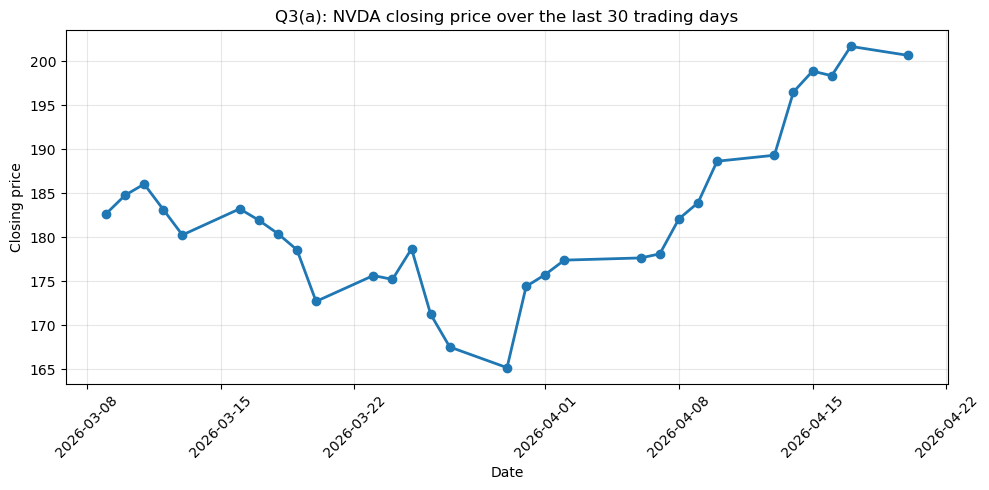

In [24]:
df = get_nvda_data()
print("Last 30 trading-day NVDA close prices:")
# print(df) 

# Part a): plot date vs stock price
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"], marker="o", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.title("Q3(a): NVDA closing price over the last 30 trading days")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("q3_nvda_raw_data.png", dpi=200)
plt.show()

#### Part b)

In [25]:
x = np.arange(len(df), dtype=float)
y = df["Close"].to_numpy(dtype=float)

sgd_out = train_sgd_linear_regression(x, y, epochs=1000, eta0=0.01, seed=0)

slope = sgd_out["slope"]
intercept = sgd_out["intercept"]

print(f"Predicted line: y_hat = {np.asarray(slope).item():.6f} * day_index + {np.asarray(intercept).item():.6f}")


Predicted line: y_hat = 0.537277 * day_index + 174.588821


#### Part c)

C:\Users\sshah\AppData\Local\Temp\ipykernel_17056\1057681503.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([df["Date"].iloc[0], df["Date"].iloc[-1]],[float(intercept), float(y_end)], linewidth=2, label="SGD regression line")


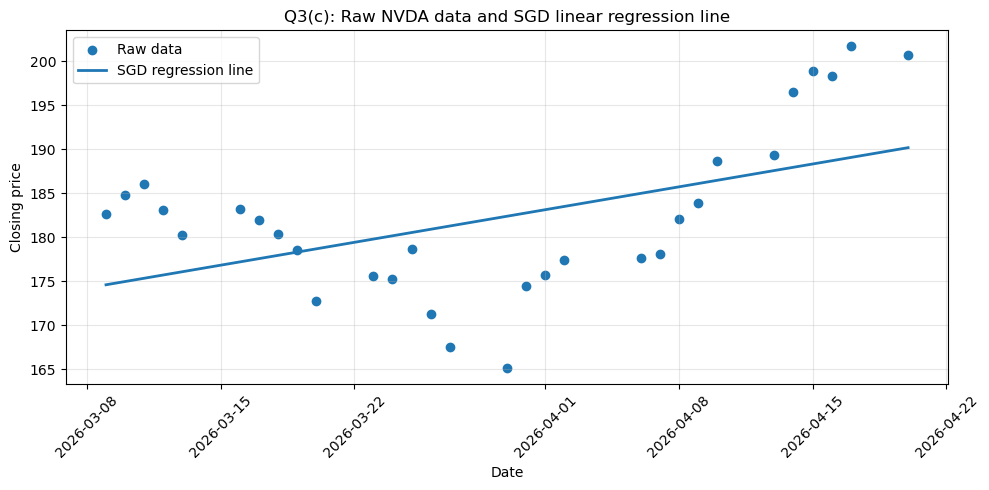

In [26]:
y_hat = slope * x + intercept

n = len(df)
y_end = slope * (n - 1) + intercept


plt.figure(figsize=(10, 5))
plt.scatter(df["Date"], y, label="Raw data")
# We do this because using just y_hat would lead the plot to look squiggly and irregular, this is due to the fact the x-axis uses dates,
# However the gap between consecture rows isn't constant (weekend/holidays) ruin the segments, so we use the code below to draw the line between endpoints
plt.plot([df["Date"].iloc[0], df["Date"].iloc[-1]],[float(intercept), float(y_end)], linewidth=2, label="SGD regression line")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.title("Q3(c): Raw NVDA data and SGD linear regression line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("q3_nvda_fit.png", dpi=200)
plt.show()

#### Part d)

In [27]:
# Approximate 3 months as 63 trading days
n_future_days = 63

# Create future day indices:
# if current data uses indices 0, 1, ..., len(df)-1
# then future indices should start at len(df)
future_indices = np.arange(len(df), len(df) + n_future_days, dtype=float)

# Predict price for every future trading day
future_predictions = slope * future_indices + intercept

# Create future business-day dates for plotting / table output
last_date = df["Date"].iloc[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

# Put predictions into a table
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Close": future_predictions
})

print("\nPart (d): Predicted NVDA prices for the next 3 months")
print(forecast_df)

# Optional: save to CSV
forecast_df.to_csv("q3_nvda_3month_forecast.csv", index=False)


Part (d): Predicted NVDA prices for the next 3 months
         Date  Predicted_Close
0  2026-04-21       190.707133
1  2026-04-22       191.244410
2  2026-04-23       191.781687
3  2026-04-24       192.318964
4  2026-04-27       192.856241
..        ...              ...
58 2026-07-10       221.869203
59 2026-07-13       222.406481
60 2026-07-14       222.943758
61 2026-07-15       223.481035
62 2026-07-16       224.018312

[63 rows x 2 columns]


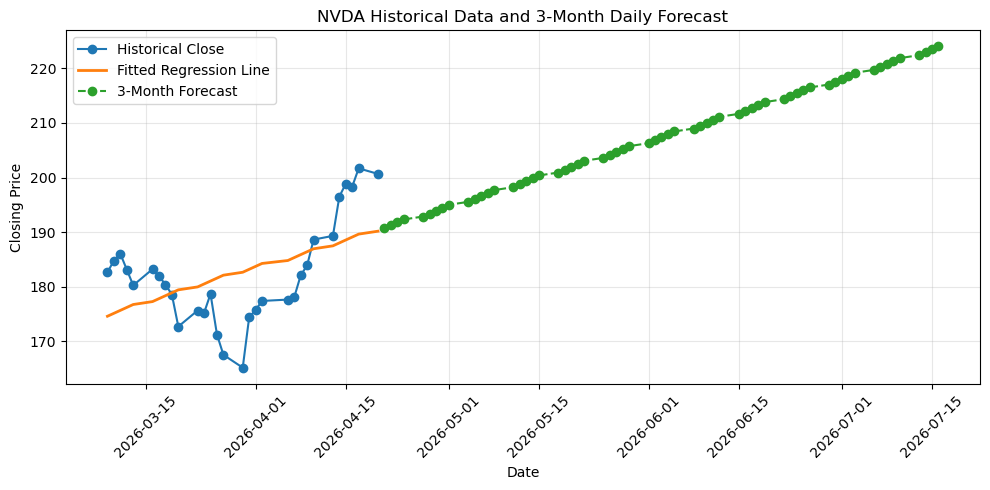

In [28]:
plt.figure(figsize=(10, 5))

# historical data
plt.plot(df["Date"], df["Close"], marker="o", label="Historical Close")

# fitted line on historical window
y_hat = slope * x + intercept
plt.plot(df["Date"], y_hat, linewidth=2, label="Fitted Regression Line")

# future forecast
plt.plot(future_dates, future_predictions, marker="o", linestyle="--", label="3-Month Forecast")

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("NVDA Historical Data and 3-Month Daily Forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("q3_nvda_daily_3month_forecast.png", dpi=200)
plt.show()

In [29]:
last = forecast_df.iloc[-1]
last_date = last["Date"]
last_pred = last["Predicted_Close"]

print(f"The final predicted price at 3 months time is {last_pred:.2f}.")

The final predicted price at 3 months time is 224.02.


#### Part e)
In gradient descent, at every step, it uses all the data points to compute the gradient of the cost function and then updates.
As the gradient is calculated using all the data, each step reflects all the data correctly, and leads to updates being consistent, allowing for better analyzation. However, Gradient Descent is good when the dataset is small, as the operations required of computing gradients over all points leads to it being very expensive per iteration. Additionally, if gradients are small, progress can significantly decrease.
x_(k+1) = x_k - alpha(deltaf(x_k))

In Stochastic Gradient Descent, rather than using all the data, SGD updates using only one data point at a time. A notable benefit is the speed per iteration, as we are only performing a singular operation each update from one data point. This leads to it being very applciable towards large datasets, the randomness of the travel also allows it to escape local minima and saddle points (Great for neural networks). However, there are a few issues, firstly, each update is based on one sample, leading to noisy updates as directions aren't exact (Objective function does not decrease smoothly). Additionally, SGD may oscillate around the minimum without ever settling due to increased difficulty in tuning the step size.
x_(k+1) = x_k - alpha(deltaf_i(x_k))

Gradient Descent is accurate but slow
Stochastic Gradient Descent is fast but noisy.